# Notebook 02 — ViT-B/16 Evaluation Across Four Settings

**Project:** Explainable Exoplanet Transit Classification  
**Platform:** Google Colab (T4 GPU)  
**Input:** `kepler_gaf_dataset.npz` — produced by Notebook 01b  
**Output:** `dissertation_results/metrics.csv` saved to Google Drive

**Four evaluation settings (in order):**
1. Zero-shot — ViT-B/16 with no adaptation at all
2. One-shot — 1 labelled example per class
3. Few-shot — small labelled sample per class
4. LoRA — low-rank fine-tuning via PEFT (r = 4, 8, 16)

**Setup before running:**
1. Upload `kepler_gaf_dataset.npz` to your Google Drive (root folder)
2. Set runtime to **GPU T4** (Runtime → Change runtime type → T4 GPU)
3. Run Cell 1 — it will ask you to authorise Google Drive access
4. Run All remaining cells

**Metrics used:** F1 (macro) and AUC-ROC — NOT raw accuracy (misleading under class imbalance)

## Section 1 — Mount Drive & Install Packages

In [ ]:
import os
from google.colab import drive

mountpoint = '/content/drive'

# Ensure the mount point is clean before attempting to mount
if os.path.exists(mountpoint):
    print(f"Removing existing mount point: {mountpoint}")
    !rm -rf {mountpoint}
os.makedirs(mountpoint, exist_ok=True) # Recreate an empty directory

# Mount Google Drive — a browser popup will ask you to authorise
drive.mount(mountpoint, force_remount=True)


# Install packages not pre-installed on Colab
# timm and peft are not included by default
!pip install timm peft -q

print("Drive mounted. Packages installed.")

Mounted at /content/drive
Drive mounted. Packages installed.


## Section 2 — Imports

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm
from torch.utils.data import Dataset, DataLoader, Subset
from pathlib import Path
import time
import warnings
warnings.filterwarnings('ignore')

from peft import LoraConfig, get_peft_model
from sklearn.metrics import f1_score, roc_auc_score
import matplotlib.pyplot as plt

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

print(f"PyTorch: {torch.__version__}")
print(f"timm:    {timm.__version__}")
print("All imports OK")

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB
PyTorch: 2.11.0+cu128
timm:    1.0.27
All imports OK


## Section 3 — Configuration

In [ ]:
# ── UPDATE THIS PATH if you saved the file in a subfolder on Drive ────────────
DATASET_PATH = Path('/content/drive/MyDrive/dessertation/kepler_gaf_dataset.npz')
# ─────────────────────────────────────────────────────────────────────────────

CFG = {
    'model_name'   : 'vit_base_patch16_224',
    'num_classes'  : 2,
    'image_size'   : 224,
    'batch_size'   : 32,
    'lr'           : 2e-4,
    'lora_epochs'  : 10,
    'lora_ranks'   : [4, 8, 16],
    'few_shot_n'   : 10,
    'random_seed'  : 42,
    # Results saved to Drive so they survive session end
    'results_dir'  : Path('/content/drive'),
}

CFG['results_dir'].mkdir(parents=True, exist_ok=True)
torch.manual_seed(CFG['random_seed'])
np.random.seed(CFG['random_seed'])

print("Config:")
for k, v in CFG.items():
    print(f"  {k}: {v}")
print(f"\nDataset path exists: {DATASET_PATH.exists()}")


Config:
  model_name: vit_base_patch16_224
  num_classes: 2
  image_size: 224
  batch_size: 32
  lr: 0.0002
  lora_epochs: 10
  lora_ranks: [4, 8, 16]
  few_shot_n: 10
  random_seed: 42
  results_dir: /content/drive

Dataset path exists: True


## Section 4 — Load Dataset

Loads `kepler_gaf_dataset.npz` produced by Notebook 01b.  
GAF images are 64×64 float32 arrays in [-1, 1].  
ViT-B/16 expects 224×224 RGB — we resize and replicate the single channel to 3 channels.

In [ ]:
data = np.load(DATASET_PATH)

X_train, y_train = data['X_train'], data['y_train']
X_val,   y_val   = data['X_val'],   data['y_val']
X_test,  y_test  = data['X_test'],  data['y_test']

print("Loaded splits:")
for name, X, y in [('train', X_train, y_train), ('val', X_val, y_val), ('test', X_test, y_test)]:
    print(f"  {name:5s}  X={str(X.shape):16s}  confirmed={y.mean():.1%}")

# Compute class weights from training split for weighted loss
n_confirmed    = y_train.sum()
n_fp           = len(y_train) - n_confirmed
w_confirmed    = len(y_train) / (2.0 * n_confirmed)
w_fp           = len(y_train) / (2.0 * n_fp)
CLASS_WEIGHTS  = torch.tensor([w_fp, w_confirmed], dtype=torch.float32).to(DEVICE)

print(f"\nClass weights — FALSE POSITIVE: {w_fp:.3f}  CONFIRMED: {w_confirmed:.3f}")

Loaded splits:
  train  X=(3710, 64, 64)    confirmed=41.4%
  val    X=(796, 64, 64)     confirmed=41.3%
  test   X=(796, 64, 64)     confirmed=41.5%

Class weights — FALSE POSITIVE: 0.853  CONFIRMED: 1.208


## Section 5 — Dataset Class & DataLoaders

In [ ]:
class GAFDataset(Dataset):
    """Wraps GAF numpy arrays. Resizes 64×64 → 224×224 and replicates to 3 channels."""
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).unsqueeze(1)
        self.y = torch.from_numpy(y).long()

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        img = self.X[idx]                                    # (1, 64, 64)
        img = F.interpolate(img.unsqueeze(0), size=224,
                            mode='bilinear',
                            align_corners=False).squeeze(0)  # (1, 224, 224)
        img = img.repeat(3, 1, 1)                            # (3, 224, 224)
        mean = torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1)
        std  = torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1)
        img  = (img - mean) / std
        return img, self.y[idx]


train_ds = GAFDataset(X_train, y_train)
val_ds   = GAFDataset(X_val,   y_val)
test_ds  = GAFDataset(X_test,  y_test)

train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'], shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=CFG['batch_size'], shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=CFG['batch_size'], shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

imgs, labels = next(iter(train_loader))
print(f"Batch shape: {imgs.shape}  labels: {labels.shape}  dtype: {imgs.dtype}")

Train batches: 116
Val batches:   25
Test batches:  25
Batch shape: torch.Size([32, 3, 224, 224])  labels: torch.Size([32])  dtype: torch.float32


## Section 6 — Evaluation Helper

A single `evaluate()` function used by all four settings.  
Returns F1 (macro) and AUC-ROC — the two primary metrics for this project.

In [ ]:
def evaluate(model, loader, device):
    """Returns (f1_macro, auc_roc, inference_ms_per_sample)."""
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    t0 = time.time()

    with torch.no_grad():
        for imgs, labels in loader:
            imgs   = imgs.to(device)
            labels = labels.to(device)
            logits = model(imgs)
            probs  = torch.softmax(logits, dim=1)[:, 1]
            preds  = logits.argmax(dim=1)
            all_preds.append(preds.cpu())
            all_probs.append(probs.cpu())
            all_labels.append(labels.cpu())

    elapsed_ms = (time.time() - t0) * 1000
    n_samples  = len(loader.dataset)

    all_preds  = torch.cat(all_preds).numpy()
    all_probs  = torch.cat(all_probs).numpy()
    all_labels = torch.cat(all_labels).numpy()

    f1  = f1_score(all_labels, all_preds, average='macro')
    auc = roc_auc_score(all_labels, all_probs)
    ms_per_sample = elapsed_ms / n_samples

    return f1, auc, ms_per_sample


results = []

def log_result(setting, f1, auc, ms):
    results.append({'setting': setting, 'f1_macro': round(f1, 4), 'auc_roc': round(auc, 4), 'ms_per_sample': round(ms, 2)})
    print(f"[{setting}]  F1={f1:.4f}  AUC={auc:.4f}  ({ms:.2f} ms/sample)")


def make_vit(num_classes=2):
    model = timm.create_model(
        'vit_base_patch16_224',
        pretrained=True,
        num_classes=num_classes,
    )
    return model


print("Evaluation helper ready.")

Evaluation helper ready.


## Section 7 — Setting 1: Zero-Shot

Load pretrained ViT-B/16 with **no adaptation**.  
The model has never seen exoplanet data — its head is randomly initialised for 2 classes.  
This is the baseline floor. We expect poor performance.

In [ ]:
print("Loading ViT-B/16 via timm (zero-shot) ...")
model_zs = make_vit().to(DEVICE)

total_params = sum(p.numel() for p in model_zs.parameters())
print(f"Total parameters: {total_params:,}")

f1, auc, ms = evaluate(model_zs, test_loader, DEVICE)
log_result('zero-shot', f1, auc, ms)

del model_zs
torch.cuda.empty_cache()

Loading ViT-B/16 via timm (zero-shot) ...


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Total parameters: 85,800,194
[zero-shot]  F1=0.5045  AUC=0.5356  (11.74 ms/sample)


## Section 8 — Setting 2: One-Shot

1 labelled example per class (2 total) used to fine-tune only the classification head.  
All ViT backbone weights remain frozen.  
Simulates the scenario where almost no labelled exoplanet data is available.

In [ ]:
def get_n_shot_loader(dataset, y_array, n_per_class, seed=42):
    rng = np.random.RandomState(seed)
    indices = []
    for cls in [0, 1]:
        cls_indices = np.where(y_array == cls)[0]
        chosen = rng.choice(cls_indices, size=n_per_class, replace=False)
        indices.extend(chosen.tolist())
    subset = Subset(dataset, indices)
    return DataLoader(subset, batch_size=len(indices), shuffle=True)


def train_head_only(model, support_loader, device, epochs=50, lr=1e-3):
    """Fine-tune only the classifier head. Backbone frozen."""
    for name, param in model.named_parameters():
        param.requires_grad = name.startswith('head')

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Trainable params: {trainable:,}")

    optimiser = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr
    )
    criterion = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS)
    model.train()

    for epoch in range(epochs):
        for imgs, labels in support_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimiser.zero_grad()
            loss = criterion(model(imgs), labels)
            loss.backward()
            optimiser.step()

    return model


print("--- One-Shot ---")
model_1s = make_vit().to(DEVICE)
support_loader_1 = get_n_shot_loader(train_ds, y_train, n_per_class=1)
model_1s = train_head_only(model_1s, support_loader_1, DEVICE)

f1, auc, ms = evaluate(model_1s, test_loader, DEVICE)
log_result('one-shot', f1, auc, ms)

del model_1s
torch.cuda.empty_cache()

--- One-Shot ---
  Trainable params: 1,538
[one-shot]  F1=0.4562  AUC=0.4636  (10.39 ms/sample)


## Section 9 — Setting 3: Few-Shot

`few_shot_n` examples per class (default 10, so 20 total).  
Same head-only fine-tuning as one-shot — backbone still frozen.  
Tests how much a small labelled set improves over one-shot.

In [ ]:
print(f"--- Few-Shot ({CFG['few_shot_n']} per class) ---")
model_fs = make_vit().to(DEVICE)
support_loader_few = get_n_shot_loader(train_ds, y_train, n_per_class=CFG['few_shot_n'])
model_fs = train_head_only(model_fs, support_loader_few, DEVICE, epochs=50)

f1, auc, ms = evaluate(model_fs, test_loader, DEVICE)
log_result(f'few-shot-{CFG["few_shot_n"]}', f1, auc, ms)

del model_fs
torch.cuda.empty_cache()

--- Few-Shot (10 per class) ---
  Trainable params: 1,538
[few-shot-10]  F1=0.7305  AUC=0.7972  (9.75 ms/sample)


In [ ]:
  !pip install -q "torchao>=0.16.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 79.2 MB/s eta 0:00:00


## Section 10 — Setting 4: LoRA Fine-Tuning

Uses PEFT to insert low-rank trainable matrices into the ViT attention layers.  
All original weights remain frozen. Only ~600K parameters are trainable (at r=8).  
Trains on the full training set. Tested at r = 4, 8, 16.


LoRA  r=4
trainable params: 147,456 || all params: 85,947,650 || trainable%: 0.1716
  Epoch 01/10  loss=0.5329  val_F1=0.7747  val_AUC=0.8702
  Epoch 02/10  loss=0.4237  val_F1=0.7845  val_AUC=0.8810
  Epoch 03/10  loss=0.3996  val_F1=0.7863  val_AUC=0.8864
  Epoch 04/10  loss=0.3762  val_F1=0.7979  val_AUC=0.8899
  Epoch 05/10  loss=0.3663  val_F1=0.7959  val_AUC=0.8921
  Epoch 06/10  loss=0.3444  val_F1=0.8022  val_AUC=0.8936
  Epoch 07/10  loss=0.3379  val_F1=0.7855  val_AUC=0.8843
  Epoch 08/10  loss=0.3278  val_F1=0.7971  val_AUC=0.8935
  Epoch 09/10  loss=0.3175  val_F1=0.7976  val_AUC=0.8938
  Epoch 10/10  loss=0.3120  val_F1=0.8008  val_AUC=0.8931
[lora-r4]  F1=0.8069  AUC=0.9091  (11.29 ms/sample)


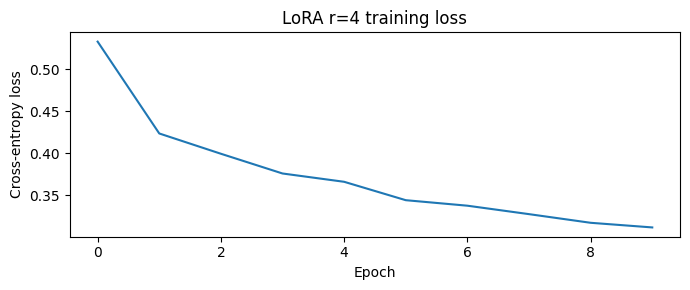


LoRA  r=8
trainable params: 294,912 || all params: 86,095,106 || trainable%: 0.3425
  Epoch 01/10  loss=0.5207  val_F1=0.7749  val_AUC=0.8724
  Epoch 02/10  loss=0.4039  val_F1=0.7878  val_AUC=0.8795
  Epoch 03/10  loss=0.3808  val_F1=0.7884  val_AUC=0.8881
  Epoch 04/10  loss=0.3569  val_F1=0.7782  val_AUC=0.8823
  Epoch 05/10  loss=0.3360  val_F1=0.7973  val_AUC=0.8933
  Epoch 06/10  loss=0.3173  val_F1=0.7971  val_AUC=0.8943
  Epoch 07/10  loss=0.2962  val_F1=0.7975  val_AUC=0.8920
  Epoch 08/10  loss=0.2786  val_F1=0.7989  val_AUC=0.8917
  Epoch 09/10  loss=0.2667  val_F1=0.8071  val_AUC=0.8941
  Epoch 10/10  loss=0.2576  val_F1=0.8061  val_AUC=0.8940
[lora-r8]  F1=0.8195  AUC=0.9096  (11.34 ms/sample)


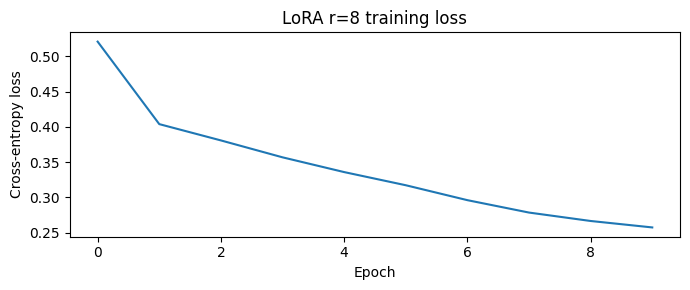


LoRA  r=16
trainable params: 589,824 || all params: 86,390,018 || trainable%: 0.6827
  Epoch 01/10  loss=0.4893  val_F1=0.7887  val_AUC=0.8764
  Epoch 02/10  loss=0.4029  val_F1=0.8019  val_AUC=0.8822
  Epoch 03/10  loss=0.3681  val_F1=0.7944  val_AUC=0.8936
  Epoch 04/10  loss=0.3428  val_F1=0.8033  val_AUC=0.8922
  Epoch 05/10  loss=0.3127  val_F1=0.7916  val_AUC=0.8913
  Epoch 06/10  loss=0.2861  val_F1=0.8076  val_AUC=0.8948
  Epoch 07/10  loss=0.2566  val_F1=0.8135  val_AUC=0.8914
  Epoch 08/10  loss=0.2300  val_F1=0.8004  val_AUC=0.8847
  Epoch 09/10  loss=0.2078  val_F1=0.8046  val_AUC=0.8891
  Epoch 10/10  loss=0.1956  val_F1=0.8061  val_AUC=0.8891
[lora-r16]  F1=0.8338  AUC=0.9106  (11.44 ms/sample)


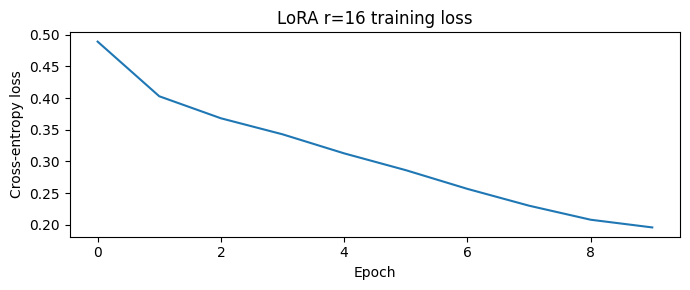

In [ ]:
def train_lora(rank, train_loader, val_loader, device, epochs, lr):
    base = make_vit()

    lora_cfg = LoraConfig(
        r=rank,
        lora_alpha=rank * 2,
        target_modules=['qkv'],
        lora_dropout=0.1,
        bias='none',
        modules_to_save=['head'], # save trained head so adapter is self-contained
    )
    model = get_peft_model(base, lora_cfg)
    model.print_trainable_parameters()
    model = model.to(device)

    optimiser = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=epochs)
    criterion = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS)

    best_val_f1  = 0.0
    best_state   = None
    train_losses = []

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0.0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimiser.zero_grad()
            loss = criterion(model(imgs), labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimiser.step()
            epoch_loss += loss.item()

        scheduler.step()
        train_losses.append(epoch_loss / len(train_loader))

        val_f1, val_auc, _ = evaluate(model, val_loader, device)
        print(f"  Epoch {epoch:02d}/{epochs}  loss={train_losses[-1]:.4f}  val_F1={val_f1:.4f}  val_AUC={val_auc:.4f}")

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state  = {k: v.clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    return model, train_losses


lora_models = {}

for r in CFG['lora_ranks']:
    print(f"\n{'='*50}")
    print(f"LoRA  r={r}")
    print('='*50)
    t_start = time.time()
    model_lora, losses = train_lora(
        rank=r,
        train_loader=train_loader,
        val_loader=val_loader,
        device=DEVICE,
        epochs=CFG['lora_epochs'],
        lr=CFG['lr'],
    )
    train_time_min = (time.time() - t_start) / 60

    f1, auc, ms = evaluate(model_lora, test_loader, DEVICE)
    log_result(f'lora-r{r}', f1, auc, ms)
    results[-1]['train_time_min'] = round(train_time_min, 1)

    lora_models[r] = model_lora
    save_path = Path('/content/drive/MyDrive/dessertation/dissertation_results')

    plt.figure(figsize=(7, 3))
    plt.plot(losses)
    plt.xlabel('Epoch')
    plt.ylabel('Cross-entropy loss')
    plt.title(f'LoRA r={r} training loss')
    plt.tight_layout()
    plt.savefig(save_path / f'lora_r{r}_loss.png', dpi=120)
    plt.show()

## Section 11 — Results Summary

In [ ]:

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('f1_macro', ascending=False).reset_index(drop=True)

print("\n=== Final Results ===")
print(results_df.to_string(index=False))

save_path.mkdir(exist_ok=True)
results_df.to_csv(save_path / 'metrics.csv', index=False)
print("Saved.")
print(f"\nSaved to {CFG['results_dir'] / 'metrics.csv'}")


=== Final Results ===
    setting  f1_macro  auc_roc  ms_per_sample  train_time_min
   lora-r16    0.8338   0.9106          11.44            16.3
    lora-r8    0.8195   0.9096          11.34            16.3
    lora-r4    0.8069   0.9091          11.29            16.2
    lora-r4    0.8066   0.9080          11.43            16.2
few-shot-10    0.7305   0.7972           9.75             NaN
  zero-shot    0.5045   0.5356          11.74             NaN
   one-shot    0.4562   0.4636          10.39             NaN
Saved.

Saved to /content/drive/metrics.csv


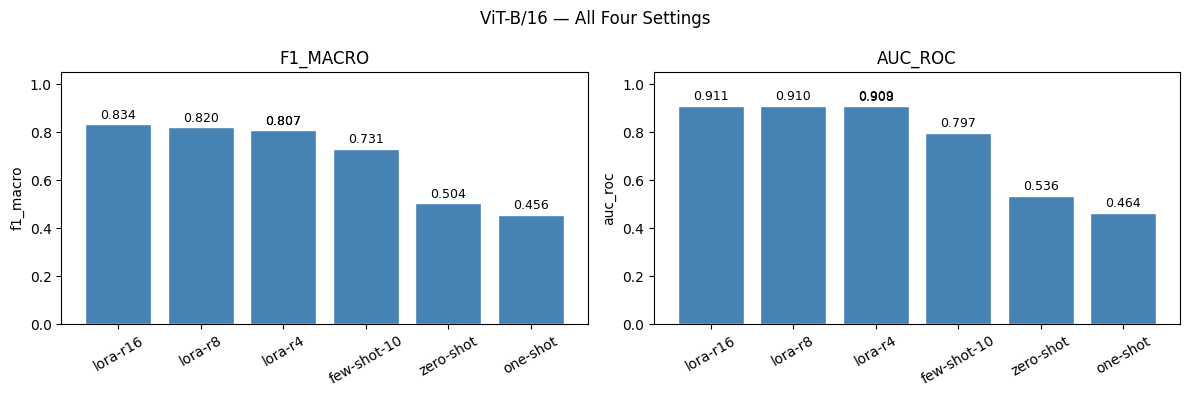


Ready for Notebook 03 — RAG Module


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

settings = results_df['setting']
for ax, metric in zip(axes, ['f1_macro', 'auc_roc']):
    bars = ax.bar(settings, results_df[metric], color='steelblue', edgecolor='white')
    ax.set_ylim(0, 1.05)
    ax.set_ylabel(metric)
    ax.set_title(metric.upper())
    ax.tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

fig.suptitle('ViT-B/16 — All Four Settings', fontsize=12)
plt.tight_layout()
plt.savefig(save_path / 'comparison_chart.png', dpi=120)
plt.show()

print("\nReady for Notebook 03 — RAG Module")

## Section 12 — Save Best LoRA Model + Detailed Evaluation

Saves the LoRA adapter **including the trained classification head** (`modules_to_save=['head']`), then generates per-class precision/recall/F1, confusion matrix PNG, and ROC curve PNG — all saved to Google Drive.

In [ ]:
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    ConfusionMatrixDisplay,
)
import json as _json

CLASS_NAMES = ['FALSE POSITIVE', 'CONFIRMED']

# Identify best LoRA rank
lora_rows = results_df[results_df['setting'].str.startswith('lora')]
best_row  = lora_rows.loc[lora_rows['f1_macro'].idxmax()]
best_rank = int(best_row['setting'].replace('lora-r', ''))
print(f"Best LoRA rank: r={best_rank}  F1={best_row['f1_macro']}  AUC={best_row['auc_roc']}")

# ── Save adapter (now includes trained head via modules_to_save) ──────────────
save_path = CFG['results_dir'] / f'best_lora_r{best_rank}'
lora_models[best_rank].save_pretrained(save_path)
print(f"Adapter saved to {save_path}")

# ── Per-class metrics, confusion matrix, ROC curve ───────────────────────────
best_model = lora_models[best_rank]
best_model.eval()

all_preds, all_probs_conf, all_labels = [], [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        logits = best_model(imgs)
        probs  = torch.softmax(logits, dim=1)
        all_preds.append(logits.argmax(dim=1).cpu().numpy())
        all_probs_conf.append(probs[:, 1].cpu().numpy())
        all_labels.append(labels.numpy())

y_pred = np.concatenate(all_preds)
y_prob = np.concatenate(all_probs_conf)
y_true = np.concatenate(all_labels)

# Per-class CSV
report = classification_report(y_true, y_pred, target_names=CLASS_NAMES, output_dict=True)
rows = []
for cls in CLASS_NAMES:
    r = report[cls]
    rows.append({'class': cls, 'precision': round(r['precision'],4),
                 'recall': round(r['recall'],4), 'f1': round(r['f1-score'],4),
                 'support': int(r['support'])})
rows.append({'class': 'macro avg',
             'precision': round(report['macro avg']['precision'],4),
             'recall':    round(report['macro avg']['recall'],4),
             'f1':        round(report['macro avg']['f1-score'],4),
             'support':   int(report['macro avg']['support'])})
per_class_df = pd.DataFrame(rows)
per_class_df.to_csv(CFG['results_dir'] / 'lora_r16_per_class_metrics.csv', index=False)
print("\nPer-class metrics:")
print(per_class_df.to_string(index=False))

# Confusion matrix PNG
auc = roc_auc_score(y_true, y_prob)
cm  = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'LoRA r={best_rank} — Confusion Matrix (Test n={len(y_true)})')
plt.tight_layout()
plt.savefig(CFG['results_dir'] / 'lora_r16_confusion_matrix.png', dpi=150)
plt.show()
print("Confusion matrix saved.")

# ROC curve PNG
fpr, tpr, _ = roc_curve(y_true, y_prob)
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(fpr, tpr, lw=1.8, label=f'LoRA r={best_rank} (AUC = {auc:.4f})')
ax.plot([0,1],[0,1],'k--',lw=0.8)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title(f'LoRA r={best_rank} — ROC Curve (Test Set)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(CFG['results_dir'] / 'lora_r16_roc_curve.png', dpi=150)
plt.show()
print(f"ROC curve saved.  AUC = {auc:.4f}")

# Summary JSON
summary = {'macro_f1': round(report['macro avg']['f1-score'],4), 'auc_roc': round(auc,4),
           'per_class': {cls: report[cls] for cls in CLASS_NAMES}}
(CFG['results_dir'] / 'lora_r16_full_metrics.json').write_text(_json.dumps(summary, indent=2))
print("\nAll outputs saved to Google Drive:", CFG['results_dir'])


Best LoRA rank: r=16  F1=0.8338  AUC=0.9106
Saved to /content/drive/MyDrive/dessertation/dissertation_results/best_lora_r16
